# ЛР-2. Gridworld: от $V(s)$ к корректной политике

**Модуль 1 · Неделя 2 · индивидуальная**

В ЛР-1 мы наблюдали цикл `Thought → Action → Observation`. Здесь формализуем цикл
«агент ↔ среда» как MDP и проверим важную инженерную мысль: **правдоподобный код может
исполняться без исключений и всё равно реализовывать неверную политику**.

MDP задаётся $(S,A,P,R,\gamma)$. Value iteration вычисляет $V^*$, но действие выбирается
не по значению соседней клетки, а по ожидаемой ценности действия:

$$Q(s,a)=\sum_{s'}P(s'\mid s,a)[R(s,a,s')+\gamma V(s')],\qquad
\pi(s)=\arg\max_a Q(s,a).$$


## 1. Цель и результат

К концу работы вы:

1. найдёте скрытый семантический баг в policy extraction;
2. отличите $V(s')$ от $Q(s,a)$;
3. получите оптимальную политику из value iteration;
4. измерите устойчивость политики к `slip`;
5. увидите, как $\gamma$ меняет выбор между близкой малой и дальней большой наградой.

**На сдачу:** выполненные задания 1–3, два графика/таблицы и вывод на 4–6 предложений.
Задание про exploration помечено ★ и не является обязательным.


## 2. Окружение

Python 3.10+, `numpy`, `matplotlib`. Сеть и API-ключи не нужны.
Если импорты не работают, выполните общую инструкцию `labs/SETUP.md`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "— окружение готово")


numpy 2.2.6 — окружение готово


## 3. Среда Gridworld

Поле $4\times4$: старт `(0,0)`, цель `(3,3)` с наградой `+1`, ловушка `(1,3)`
с наградой `−1`, обычный шаг `−0.04`. При `slip=0.1` задуманное действие выполняется
с вероятностью `0.9`, а с вероятностью `0.05` агент соскальзывает в каждую из двух
перпендикулярных сторон.


In [2]:
PERP = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

def transition_dist(action, slip):
    'P(actual_action | intended_action).'
    if action not in range(4):
        raise ValueError("action must be one of 0, 1, 2, 3")
    if not 0 <= slip <= 1:
        raise ValueError("slip must be in [0, 1]")
    dist = {action: 1 - slip}
    for perpendicular in PERP[action]:
        dist[perpendicular] = dist.get(perpendicular, 0.0) + slip / 2
    return dist


class GridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_NAMES = {0: "↑", 1: "↓", 2: "←", 3: "→"}

    def __init__(self, n=4, slip=0.1, step_cost=-0.04, gamma=0.95,
                 seed=0, terminal_rewards=None):
        if n < 2:
            raise ValueError("n must be at least 2")
        if not 0 <= gamma < 1:
            raise ValueError("gamma must be in [0, 1)")
        transition_dist(0, slip)  # validates slip
        self.n = n
        self.slip = slip
        self.step_cost = step_cost
        self.gamma = gamma
        self.start = (0, 0)
        self.goal = (n - 1, n - 1)
        self.trap = (1, n - 1)
        self.terminal_rewards = terminal_rewards or {self.goal: 1.0, self.trap: -1.0}
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.pos = self.start
        return self.pos

    def is_terminal(self, state):
        return state in self.terminal_rewards

    def reward_for(self, next_state):
        return self.terminal_rewards.get(next_state, self.step_cost)

    def _clip(self, row, column):
        return (min(max(row, 0), self.n - 1),
                min(max(column, 0), self.n - 1))

    def next_state(self, state, actual_action):
        dr, dc = self.ACTIONS[actual_action]
        return self._clip(state[0] + dr, state[1] + dc)

    def step(self, intended_action):
        dist = transition_dist(intended_action, self.slip)
        actions = list(dist)
        probabilities = list(dist.values())
        actual_action = int(self.rng.choice(actions, p=probabilities))
        next_state = self.next_state(self.pos, actual_action)
        self.pos = next_state
        return next_state, self.reward_for(next_state), self.is_terminal(next_state)


env = GridWorld()
print("states:", env.n ** 2, "actions:", len(env.ACTIONS),
      "gamma:", env.gamma, "slip:", env.slip)


states: 16 actions: 4 gamma: 0.95 slip: 0.1


## 4. Value iteration и $Q(s,a)$

`value_iteration` применяет уравнение Беллмана до сходимости. Обратите внимание:
терминальные состояния имеют `V=0`, потому что `+1/−1` выдаётся **при переходе** в них.
Поэтому при выборе действия нельзя просто искать соседа с максимальным `V` — нужно учитывать
немедленную награду.


In [3]:
def action_value_from_V(env, V, state, action):
    'Expected one-step return Q(s,a) under the environment model.'
    q = 0.0
    for actual_action, probability in transition_dist(action, env.slip).items():
        next_state = env.next_state(state, actual_action)
        q += probability * (env.reward_for(next_state) + env.gamma * V[next_state])
    return q


def value_iteration(env, theta=1e-8, max_iter=10_000):
    V = np.zeros((env.n, env.n))
    for iteration in range(1, max_iter + 1):
        new_V = V.copy()
        for row in range(env.n):
            for column in range(env.n):
                state = (row, column)
                if env.is_terminal(state):
                    continue
                new_V[state] = max(
                    action_value_from_V(env, V, state, action)
                    for action in env.ACTIONS
                )
        delta = np.max(np.abs(new_V - V))
        V = new_V
        if delta < theta:
            return V
    raise RuntimeError("value iteration did not converge")


Vstar = value_iteration(env)
print("Value iteration converged")
print(Vstar)


Value iteration converged
[[0.551 0.615 0.612 0.457]
 [0.626 0.701 0.703 0.   ]
 [0.705 0.793 0.887 0.985]
 [0.785 0.882 0.985 0.   ]]


## 5. Bug: код работает, политика — нет

Ниже представлена ошибочная идея. Она выбирает действие по `V` детерминированного
соседа. Код выглядит правдоподобно и не падает, но не вычисляет $Q(s,a)$.

Перед следующей ячейкой сформулируйте гипотезу: **что произойдёт в клетке `(3,2)`, которая
находится непосредственно слева от цели?**


In [4]:
def buggy_policy_from_V(env, V):
    policy = {}
    for row in range(env.n):
        for column in range(env.n):
            state = (row, column)
            if env.is_terminal(state):
                policy[state] = None
                continue
            best_action, best_neighbor_value = None, -np.inf
            for action in env.ACTIONS:
                next_state = env.next_state(state, action)  # BUG: no R and no expectation over slip
                if V[next_state] > best_neighbor_value:
                    best_neighbor_value, best_action = V[next_state], action
            policy[state] = best_action
    return policy


def run_episode(env, policy_fn, max_steps=100, seed=None):
    if seed is not None:
        env.rng = np.random.default_rng(seed)
    state = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        state, reward, done = env.step(policy_fn(state))
        total_reward += reward
        if done:
            break
    return total_reward


bug_env = GridWorld(slip=0.0)
bug_V = value_iteration(bug_env)
bug_policy = buggy_policy_from_V(bug_env, bug_V)
bug_return = run_episode(bug_env, lambda state: bug_policy[state], seed=0)
print("action at (3,2):", bug_env.ACTION_NAMES[bug_policy[(3, 2)]])
print("return with slip=0:", round(bug_return, 3))


action at (3,2): ↓
return with slip=0: -4.0


### Задание 1 — диагноз (обязательное)

Ответьте в 2–3 предложениях:

1. Почему агент не входит в цель даже при `slip=0`?
2. Чем `argmax V(s')` отличается от `argmax Q(s,a)` в этой среде?


**Ваш диагноз:**

Агент не входит в цель даже при `slip=0`, потому что ошибочная политика сравнивает только `V(s')` соседних клеток и игнорирует немедленную награду за переход. Терминальное состояние имеет `V(terminal)=0`, поэтому `argmax V(s')` может предпочесть обычную соседнюю клетку, тогда как `argmax Q(s,a)` учитывает и `R(s,a,s')`, и дисконтированную ценность всех возможных исходов перехода.


## 6. Корректная политика: $\arg\max_a Q(s,a)$


In [5]:
def greedy_policy_from_V(env, V):
    policy = {}
    for row in range(env.n):
        for column in range(env.n):
            state = (row, column)
            if env.is_terminal(state):
                policy[state] = None
                continue
            policy[state] = max(
                env.ACTIONS,
                key=lambda action: action_value_from_V(env, V, state, action),
            )
    return policy


optimal_policy = greedy_policy_from_V(env, Vstar)
print("Оптимальная политика:")
for row in range(env.n):
    print(" ".join(
        env.ACTION_NAMES.get(optimal_policy[(row, column)], "·")
        for column in range(env.n)
    ))

det_env = GridWorld(slip=0.0)
det_V = value_iteration(det_env)
det_policy = greedy_policy_from_V(det_env, det_V)
print("return при slip=0:", run_episode(det_env, lambda state: det_policy[state], seed=0))


Оптимальная политика:
↓ ↓ ↓ ←
↓ ↓ ↓ ·
→ → ↓ ↓
→ → → ·
return при slip=0: 0.8


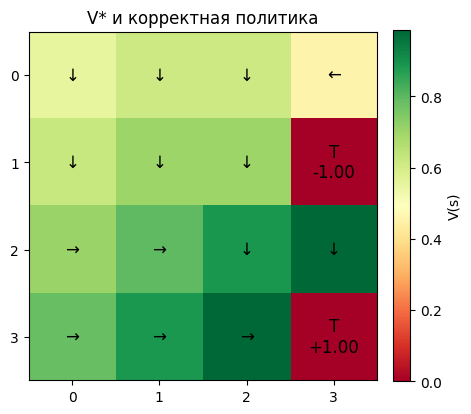

In [6]:
def plot_grid(env, V, policy, title="Ценность и политика"):
    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    image = ax.imshow(V, cmap="RdYlGn")
    for row in range(env.n):
        for column in range(env.n):
            state = (row, column)
            if state in env.terminal_rewards:
                label = f"T\n{env.terminal_rewards[state]:+.2f}"
            else:
                label = env.ACTION_NAMES[policy[state]]
            ax.text(column, row, label, ha="center", va="center", fontsize=12)
    ax.set_xticks(range(env.n)); ax.set_yticks(range(env.n))
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="V(s)")
    plt.tight_layout(); plt.show()


plot_grid(env, Vstar, optimal_policy, "V* и корректная политика")


## 7. Оценивание политики

Одного среднего return мало: отдельно считаем долю цели, долю ловушки и среднее число шагов.


In [7]:
def run_episode_details(env, policy_fn, max_steps=100, seed=None):
    if seed is not None:
        env.rng = np.random.default_rng(seed)
    state = env.reset()
    total_reward = 0.0
    for step in range(1, max_steps + 1):
        state, reward, done = env.step(policy_fn(state))
        total_reward += reward
        if done:
            return {"return": total_reward, "terminal": state, "steps": step}
    return {"return": total_reward, "terminal": None, "steps": max_steps}


def evaluate_policy(policy, env_factory, episodes=300):
    results = []
    for seed in range(episodes):
        episode_env = env_factory(seed)
        results.append(run_episode_details(
            episode_env, lambda state: policy[state], seed=seed
        ))
    returns = np.array([result["return"] for result in results])
    terminals = [result["terminal"] for result in results]
    steps = np.array([result["steps"] for result in results])
    sample_env = env_factory(0)
    return {
        "mean_return": float(returns.mean()),
        "std_return": float(returns.std()),
        "goal_rate": terminals.count(sample_env.goal) / episodes,
        "trap_rate": terminals.count(sample_env.trap) / episodes,
        "mean_steps": float(steps.mean()),
    }


baseline_metrics = evaluate_policy(
    optimal_policy, lambda seed: GridWorld(slip=0.1, seed=seed)
)
baseline_metrics


{'mean_return': 0.7710666666666665,
 'std_return': 0.05195057480165377,
 'goal_rate': 1.0,
 'trap_rate': 0.0,
 'mean_steps': 6.723333333333334}

## 8. Обязательные эксперименты

### Задание 2 — robustness к `slip`

Возьмите политику, рассчитанную для `slip=0.1`, и **не переобучайте/не пересчитывайте её**.
Испытайте ту же политику при фактическом `slip ∈ {0.0, 0.1, 0.2, 0.4}`. Постройте
графики `goal_rate` и `mean_return` от `slip`.

Ответьте: при каком расхождении между моделью и реальной средой политика становится хрупкой?


slip | goal_rate | trap_rate | mean_return | mean_steps
0.0  | 1.000     | 0.000     | 0.800       | 6.00
0.1  | 1.000     | 0.000     | 0.771       | 6.72
0.2  | 1.000     | 0.000     | 0.741       | 7.47
0.4  | 0.957     | 0.043     | 0.570       | 9.58


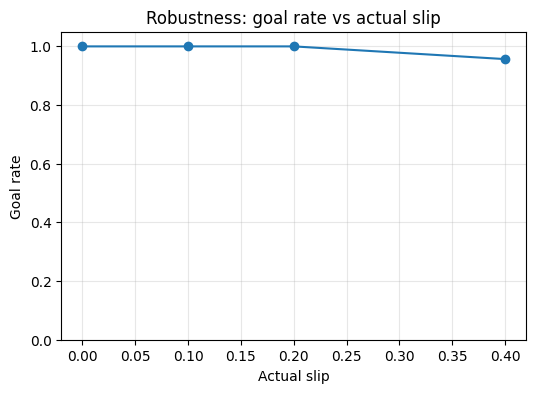

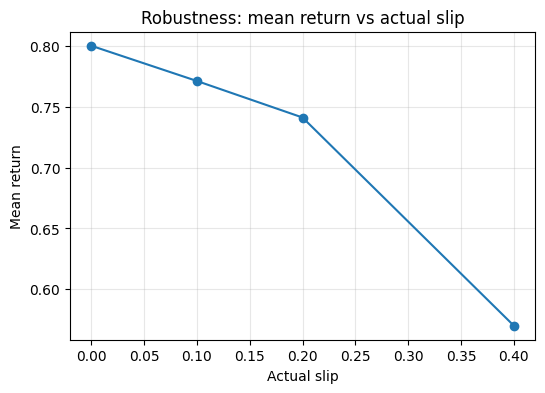


Вывод: политика рассчитана для slip=0.1 и остаётся достаточно устойчивойпри небольшом mismatch (0.0–0.2), но при actual slip=0.4 заметно падаютgoal_rate и mean_return — здесь model mismatch становится существенным.


In [8]:
slip_values = [0.0, 0.1, 0.2, 0.4]
slip_results = []

# ВАЖНО: optimal_policy уже рассчитана выше для model slip=0.1.
# Здесь меняем только фактический slip среды и НЕ пересчитываем policy.
for actual_slip in slip_values:
    metrics = evaluate_policy(
        optimal_policy,
        lambda seed, s=actual_slip: GridWorld(slip=s, seed=seed),
        episodes=300,
    )
    slip_results.append({"slip": actual_slip, **metrics})

print("slip | goal_rate | trap_rate | mean_return | mean_steps")
for result in slip_results:
    print(f"{result['slip']:.1f}  | {result['goal_rate']:.3f}     | "
          f"{result['trap_rate']:.3f}     | {result['mean_return']:.3f}       | "
          f"{result['mean_steps']:.2f}")

xs = [r["slip"] for r in slip_results]
goal_rates = [r["goal_rate"] for r in slip_results]
mean_returns = [r["mean_return"] for r in slip_results]

plt.figure(figsize=(6, 4))
plt.plot(xs, goal_rates, marker="o")
plt.xlabel("Actual slip")
plt.ylabel("Goal rate")
plt.title("Robustness: goal rate vs actual slip")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(xs, mean_returns, marker="o")
plt.xlabel("Actual slip")
plt.ylabel("Mean return")
plt.title("Robustness: mean return vs actual slip")
plt.grid(alpha=0.3)
plt.show()

# Краткая интерпретация
print("\nВывод: политика рассчитана для slip=0.1 и остаётся достаточно устойчивой"
      "при небольшом mismatch (0.0–0.2), но при actual slip=0.4 заметно падают"
      "goal_rate и mean_return — здесь model mismatch становится существенным.")


### Задание 3 — $\gamma$ как выбор горизонта

В исходной среде изменение $\gamma$ почти не меняло политику: там была одна положительная цель.
Поэтому используем честный контрпример с двумя терминалами:

- близкий `(0,2)` даёт `+0.25`;
- дальний `(3,3)` даёт `+1.0`;
- `slip=0`, чтобы не смешивать эффекты.

Постройте политики для `γ=0.5` и `γ=0.99`. Какое первое действие выбирается из старта и почему?


gamma=0.5: первое действие →


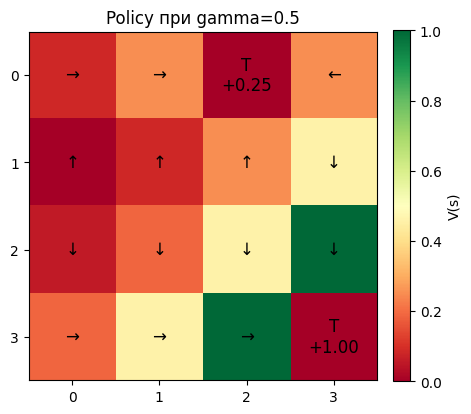

gamma=0.99: первое действие ↓


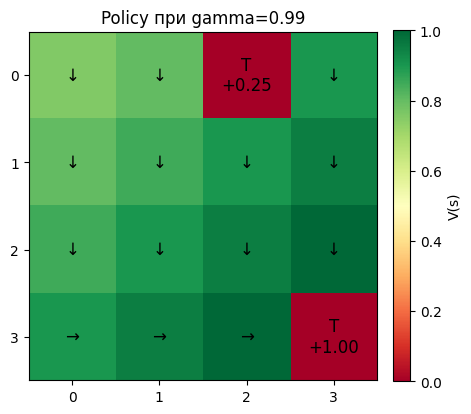

При gamma=0.5 агент выбирает короткий путь к +0.25, потому что дальняянаграда +1 сильно дисконтируется. При gamma=0.99 будущая награда почтине обесценивается, поэтому выгоднее длинный путь к +1.


In [9]:
choice_rewards = {(0, 2): 0.25, (3, 3): 1.0}
gamma_policies = {}

for gamma in [0.5, 0.99]:
    choice_env = GridWorld(
        slip=0.0,
        gamma=gamma,
        terminal_rewards=choice_rewards,
    )
    V_choice = value_iteration(choice_env)
    policy_choice = greedy_policy_from_V(choice_env, V_choice)
    gamma_policies[gamma] = policy_choice

    first_action = policy_choice[(0, 0)]
    print(f"gamma={gamma}: первое действие {choice_env.ACTION_NAMES[first_action]}")
    plot_grid(choice_env, V_choice, policy_choice, f"Policy при gamma={gamma}")

print("При gamma=0.5 агент выбирает короткий путь к +0.25, потому что дальняя"
      "награда +1 сильно дисконтируется. При gamma=0.99 будущая награда почти"
      "не обесценивается, поэтому выгоднее длинный путь к +1.")


### Вывод (обязательный, 4–6 предложений)

Объясните:

- в чём состоял баг `argmax V(s')`;
- почему случайность среды (`slip`) не равна exploration;
- как model mismatch влияет на политику;
- почему `γ` изменил выбор между двумя целями.


**Ваш вывод:**

ошибка была в том, что политика выбирала действие через `argmax V(s')`, хотя правильнее использовать `Q(s,a)`, так как он учитывает награду и вероятность разных переходов. `slip` отвечает за случайность переходов в среде, а exploration нужен, когда агент пробует разные действия, чтобы понять, какие из них лучше. политика, рассчитанная для `slip=0.1`, хорошо работает при похожих значениях, но при `slip=0.4` результаты становятся хуже, то есть снижаются `goal_rate` и `mean_return`. параметр `γ` влияет на то, насколько важны для агента будущие награды. если `γ` маленький, агент чаще выбирает ближайшую цель, а при `γ=0.99` готов пройти более длинный путь ради награды `+1`.


## 9. ★ Stretch: exploration при неизвестных оценках

В Gridworld выше модель $P,R$ известна и $V^*$ уже вычислена — добавлять случайные действия к
оптимальной политике бессмысленно. Чтобы честно увидеть роль ε-greedy, используем bandit:
три действия имеют неизвестные вероятности успеха. Агент видит только полученные награды и
обновляет эмпирические оценки.


In [10]:
def run_bandit(probabilities=(0.2, 0.5, 0.8), steps=300, epsilon=0.0,
               optimistic_value=0.0, seed=0):
    rng = np.random.default_rng(seed)
    estimates = np.full(len(probabilities), optimistic_value, dtype=float)
    counts = np.zeros(len(probabilities), dtype=int)
    cumulative = np.zeros(steps)
    total = 0.0
    for step in range(steps):
        if rng.random() < epsilon:
            action = int(rng.integers(len(probabilities)))
        else:
            best = np.flatnonzero(estimates == estimates.max())
            action = int(rng.choice(best))
        reward = float(rng.random() < probabilities[action])
        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]
        total += reward
        cumulative[step] = total
    return cumulative, counts, estimates


# TODO ★: усредните 100 запусков greedy, epsilon=0.1 и optimistic_value=1.0.
# Сравните cumulative reward и количество проб каждого действия.


## 10. Критерии оценки

| Критерий | Вес |
|---|---:|
| Диагноз бага: различает `V(s')` и `Q(s,a)` | 30% |
| Эксперимент по `slip` воспроизводим и интерпретирован | 30% |
| Эксперимент по `γ` показывает выбор горизонта | 25% |
| Вывод использует термины MDP корректно | 15% |

Задание ★ не влияет на зачёт.


## 11. Самопроверка

В student notebook часть проверок остаётся ❌, пока обязательные задания не выполнены.


In [11]:
print("=" * 12, "САМОПРОВЕРКА", "=" * 12)

def check(name, condition):
    try:
        passed = bool(condition())
    except Exception:
        passed = False
    print(("✅" if passed else "❌"), name)

check("P(.|a) нормирована", lambda: all(
    np.isclose(sum(transition_dist(action, 0.2).values()), 1.0)
    for action in env.ACTIONS
))
check("перед целью политика идёт вправо", lambda: det_policy[(3, 2)] == 3)
check("при slip=0 цель достигнута", lambda: np.isclose(
    run_episode(GridWorld(slip=0.0), lambda state: det_policy[state], seed=0), 0.8
))
check("задание 2: четыре результата", lambda: len(slip_results) == 4)
check("задание 3: построены две политики", lambda: set(gamma_policies) == {0.5, 0.99})
check("задание 3: первое действие различается", lambda:
      gamma_policies[0.5][(0, 0)] != gamma_policies[0.99][(0, 0)])


============ САМОПРОВЕРКА ============
✅ P(.|a) нормирована
✅ перед целью политика идёт вправо
✅ при slip=0 цель достигнута
✅ задание 2: четыре результата
✅ задание 3: построены две политики
✅ задание 3: первое действие различается


## 12. Литература

- Sutton & Barto, гл. 3 — конечные MDP.
- AIMA, гл. 17 §17.1–17.3 — последовательные решения и MDP.
- Sutton & Barto, §2.7 — optimistic initial values, только для задания ★.

Полная библиография курса: [`../REFERENCES.md`](../REFERENCES.md).
